# How to scale LLM inference


## Overview
There are many different configurations to run LLM inference. Each configurations has different latency (TPOT, time per output token) and throughput (MFU, model flops utilization). Each dots in following diagram represents one configuration:


/tmp/ipykernel_47085/3206806460.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


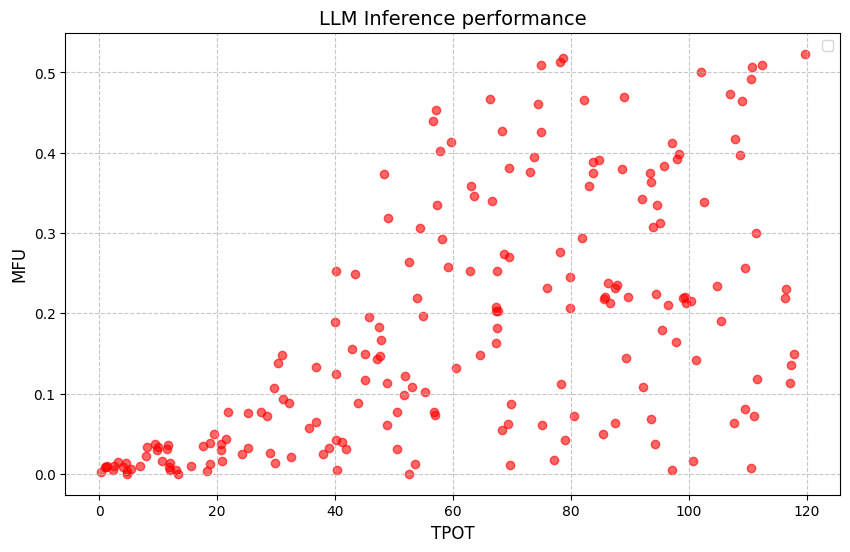

In [4]:

import numpy as np
import matplotlib.pyplot as plt
def get_mfu(x):
    growth_phase = 1.0 / (1.0 + np.exp(-0.1 * (x - 40)))
    peak_level = 0.55
    
    mfu = peak_level * growth_phase
    mfu += 0.015 * np.sin(x / 8)
    
    return np.clip(mfu, 0.01, 0.58)


x = np.linspace(0, 120, 100)

y_line = [get_mfu(tpot) for tpot in  x] 

num_points = 200
x_points = np.random.uniform(min(x), max(x), num_points)

y_points = []
for x_val in x_points:
    max_y = get_mfu(x_val)
    y_points.append(np.random.uniform(0, max_y))
y_points = np.array(y_points)

plt.figure(figsize=(10, 6))

# plt.plot(x, y_line, 'b-', linewidth=2)

plt.scatter(x_points, y_points, c='r', alpha=0.6)

plt.title('LLM Inference performance', fontsize=14)
plt.xlabel('TPOT', fontsize=12)
plt.ylabel('MFU', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig('images/llm-inference/raw-perf.png')
plt.show()

There are too many different configurations that it is impossible to run benchmarks on all of them and put them all in one diagram. And we don't need to. Because in this limited examples, we can already identify that there are configurations that is strickly better than others: the left-top side. 

For a given model and a hardware, there should be function which takes a TPOT as input and return the optimal MFU. We called it "optimal TPOT-MFU function for LLM inference". And for the configurations that can acheive the MFU & TPOT for that function, we called them optimal configurations.

/tmp/ipykernel_47085/252547320.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


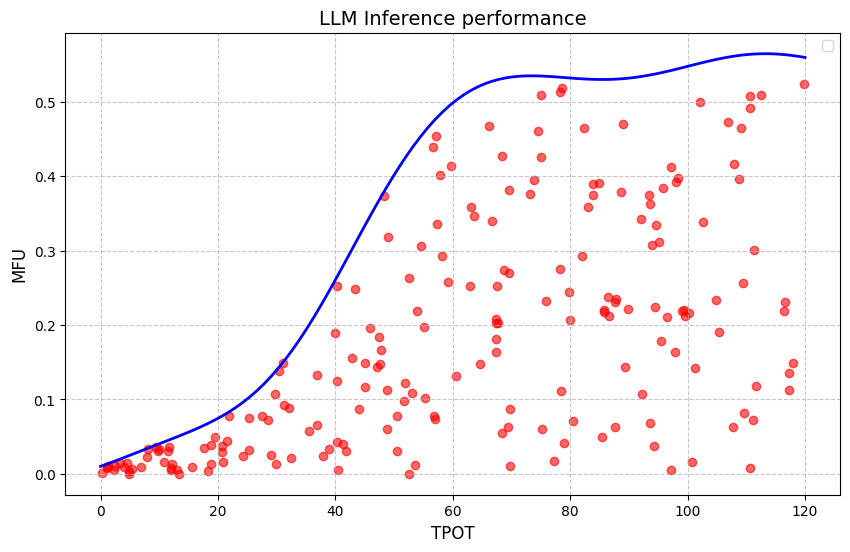

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(x, y_line, 'b-', linewidth=2)

plt.scatter(x_points, y_points, c='r', alpha=0.6)

plt.title('LLM Inference performance', fontsize=14)
plt.xlabel('TPOT', fontsize=12)
plt.ylabel('MFU', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig('images/llm-inference/opt-perf.png')

plt.show()

So the goal for LLM inference performance tuning are:
1. Identify the "optimal TPOT-MFU function for LLM inference" (the blue line)
2. Set the TPOT SLA for your LLM inference, and you should be able to get the optimal configuration and optimal MFU.
3. Optimize your LLM inference stack to acheive the optimal MFU.

In this blog, we will show you how to identify the "optimal TPOT-MFU function for LLM inference" (#1) and how to optimize your LLM inference stack to acheive the optimal MFU (#3).

## Notation used in this blog

| Notation | Description |
| --- | --- |
| $B$ | Number of tokens globally |
| $D$ | Hidden size |
| $H_{q}$ | Number of query's attention heads |
| $H_{kv}$ | Number of kv's attention heads |
| $HD$ | Head dimension |
| $L$ | Number of layers |
| $M_{param}$ | Total number of parameters for the model |
| $M_{compute}$ | Number of triggerred parameters for each token. For a dense LLM, $M_{compute} == M_{param}$. For a MOE LLM, $M_{compute} < M_{param}$. |
| $T_{w}$ | Number of bytes for the datatype of weights |
| $T_{kv}$ | Number of bytes for the datatype of kv |
| $Input$ | Input length for a request |
| $Output$ | Output length for a request |
| $QPS$ | QPS per chips |
| $Flops$ | Flops/s for the given hardware |
| $BW$ | HBM bandwidth for the given hardware |
| $W_{nvlink}$ | Nvlink bandwidth for the given hardware |
| $W_{rdma}$ | RDMA bandwidth for the given hardware |
| $P$ | Number of chips with nvlink |

## How to calculate MFU for LLM inference?

There are 2 computation density stage in LLM: MLP & Attn.

| Stage | Required Flops | Required HBM data movement |
| --- | --- | --- |
| MLP | $2*QPS*(Input+Output)*M_{compute}$ |  $\frac{2*QPS*(Input+Output)}{B}*M_{params}*T_{w}$ |
| Attn| $2*QPS*Input*(Input+Output)*H_{q}*HD*L $ | $QPS*Output*(2*Input + Output)*H_{kv}*HD*L*T_{kv}$ |

So the MFU of LLM inference is:
$$
MFU = \frac{2*QPS*(Input+Output)*M_{compute} + 2*QPS*Input*(Input+Output)*H_{q}*HD*L}{flops}
$$

Following three parts can potentially be the bottleneck of LLM inference performance:

### 1. MLP computation (most common)
LLM has very large $M_{compute}$ and $M_{params}$. So in most case, MLP part will dominate e2e performance. To acheive high MFU in this case, we want to make sure walltime for computation is larger than walltime for HBM data movement.
$$
\frac{2*QPS*(Input+Output)*M_{compute}}{flops} > \frac{2*QPS*(Input+Output)*M_{params}*T_{w}}{B*BW}
$$
$$
B > \frac{M_{params} * T_{w} * flops}{2*M_{compute} * BW}
$$
So the key of performance in this common case is to have a good batching strategy to ensure in each step, there is enough tokens to compute.

Here is the $B$ for some popular models on the same hardware:

|Hardware|Model|$B$|
| --- | --- | --- |
| H100 | qwen3-32B-w16a16c16| 295|
| H100 | qwen3-32B-w8a8c8| 295|
| H100 | qwen3-30B-A3B-w16a16c16| 2952|
| H100 | qwen3-235B-A22B-w16a16c16| 3154|
| H100 | deepseek-v3-w8a8c8| 6603|

Dense model is relatively easy to acheive high MFU. But MOE model is much harder since it requires larger number of tokens in each step. And the datatype won't impact $B$.

Here is the $B$ for the same models on different hardwares:

|Hardware|Model|$num\_tokens\_per\_batch$|
| --- | --- | --- |
| H100 | qwen3-30B-A3B-w16a16c16| 2952|
| H100 | qwen3-30B-A3B-w8a8c8| 2952|
| A100 | qwen3-30B-A3B-w16a16c16| 1560|
| H20 | qwen3-30B-A3B-w16a16c16| 370|
| L40s | qwen3-30B-A3B-w16a16c16| 4190|
| L20 | qwen3-30B-A3B-w16a16c16| 1389|

Among these hardwares, it is easier to acheive high MFU on H20 since it has highest $BW/Flops$ ratio.


In [7]:
@dataclass
class Hardware:
    name: str
    flops: int
    bw: int
    w_nvlink: int
    w_rdma: int
    p: int

@dataclass
class Model:
    name: str
    m_compute: int
    m_params: int
    hidden_dim: int
    q_head: int
    kv_head: int
    head_dim: int
    layer_num: int

@dataclass
class Dtype:
    compute_factor: int
    w_factor: int
    

hardware_map = {
    "H100": Hardware("H100", 989, 3350, 450, 50, 8),
    "A100": Hardware("A100", 312, 2000, 200, 25, 8),
    "H20": Hardware("H20", 148, 4000, 450, 50, 8),
    "L40s": Hardware("L40s", 362, 864, 25, 25, 1),
    "L20": Hardware("L20", 120, 864, 25, 25, 1),
}

model_map = {
    "qwen3-32B": Model("qwen3-32B", 32, 32, 5120, 64, 8, 128, 64),
    "qwen3-30B-A3B": Model("qwen3-30B-A3B", 3, 30, 2048, 32, 4, 128, 48),
    "qwen3-235B-A22B": Model("qwen3-235B-A22B", 22, 235, 4096, 64, 4, 128, 94),
    "deepseek-v3": Model("deepseek-v3", 30, 671, 7168, 128, 4, 128, 61),
}

dtype_map = {
    "w16a16c16": Dtype(1, 2),
    "w8a8c8": Dtype(2, 1),
}


def print_min_batch(hw, model, type):
    if type == "w16a16c16":
        compute_factor = 1
        w_factor = 2
    elif type == "w8a8c8":
        compute_factor = 2
        w_factor = 1
    else:
        raise ValueError(f"Unknown type {type}")
    
    batch = w_factor*model.m_params*hw.flops*compute_factor*1e3 / (2*model.m_compute*hw.bw)
    print(f"| {hw.name} | {model.name}-{type}| {batch:0.0f}|")

print_min_batch(hardware_map["H100"],model_map["qwen3-32B"], "w16a16c16")
print_min_batch(hardware_map["H100"],model_map["qwen3-32B"], "w8a8c8")
print_min_batch(hardware_map["H100"],model_map["qwen3-30B-A3B"], "w16a16c16")
print_min_batch(hardware_map["H100"],model_map["qwen3-235B-A22B"], "w16a16c16")
print_min_batch(hardware_map["H100"],model_map["deepseek-v3"], "w8a8c8")

print("\n")

print_min_batch(hardware_map["H100"],model_map["qwen3-30B-A3B"], "w16a16c16")
print_min_batch(hardware_map["H100"],model_map["qwen3-30B-A3B"], "w8a8c8")
print_min_batch(hardware_map["A100"],model_map["qwen3-30B-A3B"], "w16a16c16")
print_min_batch(hardware_map["H20"],model_map["qwen3-30B-A3B"], "w16a16c16")
print_min_batch(hardware_map["L40s"],model_map["qwen3-30B-A3B"], "w16a16c16")
print_min_batch(hardware_map["L20"],model_map["qwen3-30B-A3B"], "w16a16c16")


| H100 | qwen3-32B-w16a16c16| 295|
| H100 | qwen3-32B-w8a8c8| 295|
| H100 | qwen3-30B-A3B-w16a16c16| 2952|
| H100 | qwen3-235B-A22B-w16a16c16| 3154|
| H100 | deepseek-v3-w8a8c8| 6603|


| H100 | qwen3-30B-A3B-w16a16c16| 2952|
| H100 | qwen3-30B-A3B-w8a8c8| 2952|
| A100 | qwen3-30B-A3B-w16a16c16| 1560|
| H20 | qwen3-30B-A3B-w16a16c16| 370|
| L40s | qwen3-30B-A3B-w16a16c16| 4190|
| L20 | qwen3-30B-A3B-w16a16c16| 1389|



### 2. Attn computation
Attn computation will become the blocker of e2e performance when:
$$
2*QPS*Input*(Input+Output)*H_{q}*HD*L > 2*QPS*(Input+Output)*M_{compute}
$$
$$
Input > \frac{M_{compute}}{H_{q}*HD*L}
$$
To acheive high MFU in this case, we also want to make sure attn computation won't wait for HBM data movement.
$$
\frac{2*QPS*Input*(Input+Output)*H_{q}*HD*L}{flops} > \frac{QPS*Output*(2*Input + Output)*H_{kv}*HD*L*T_{kv}}{BW}
$$
$$
Output < Input * \frac{H_{q} * BW}{H_{kv} * T_{kv} * flops}
$$
Output needs to be small enough to ensure it doesn't bottleneck by HBM data movement. And the ratio between input & output is mainly impact by $H_{q}/H_{kv}$.

Here are the $Input$ and $Output$ when Attn computation is the bottleneck:

| Hardware | Model | minimum Input length | maximum Output length | input:output ratio |
|--|--|--|--|--|
| H100 | qwen3-32B| 61035| 827| 74|
| H100 | qwen3-32B| 61035| 827| 74|
| A100 | qwen3-32B| 61035| 1565| 39|
| H100 | qwen3-30B-A3B| 15259| 207| 74|
| H20 | qwen3-30B-A3B| 15259| 1650| 9|
| H100 | qwen3-235B-A22B| 28570| 774| 37|
| H100 | qwen3-235B-A22B| 28570| 774| 37|
| H100 | deepseek-v3| 30017| 1627| 18|

So we can see that if input length is larger than 15K~60K, it becomes the bottleneck of e2e performance. And it is irrelevant to hardware or data type. 



| Stage | Computation cost | HBM bandwidth cost |
| --- | --- | --- |
| MLP | $2*B*M_{compute} / Flops$ | $M_{params} / BW$ |
| Prefill Attn| $4*Seq_{q}*Seq_{kv}*H_{q}*HD*L / Flops $ | $2*Seq_{kv}*H_{kv}*HD*L / BW$ |
| Decode Attn| $4*B*Seq_{kv}*H_{q}*HD*L / Flops $ | $2*B*Seq_{kv}*H_{kv}*HD*L / BW$ |

From the above table, we can see

In [12]:
def print_attn_compute_bound(hw, model, dtype):
    h = hardware_map[hw]
    m = model_map[model]
    d = dtype_map[dtype]
    input_length = m.m_compute*1e9 / (m.q_head * m.head_dim * m.layer_num)
    output_length = input_length * m.q_head * h.bw / (m.kv_head * h.flops*d.compute_factor * 1e3*d.w_factor)
    print(f"| {hw} | {model}| {input_length:.0f}| {output_length:.0f}| {input_length/output_length:.0f}|")

print_attn_compute_bound("H100","qwen3-32B","w16a16c16")
print_attn_compute_bound("H100","qwen3-32B","w8a8c8")
print_attn_compute_bound("A100","qwen3-32B","w8a8c8")
print_attn_compute_bound("H100","qwen3-30B-A3B","w16a16c16")
print_attn_compute_bound("H20","qwen3-30B-A3B","w16a16c16")
print_attn_compute_bound("H100","qwen3-235B-A22B","w16a16c16")
print_attn_compute_bound("H100","qwen3-235B-A22B","w8a8c8")
print_attn_compute_bound("H100","deepseek-v3","w8a8c8")

| H100 | qwen3-32B| 61035| 827| 74|
| H100 | qwen3-32B| 61035| 827| 74|
| A100 | qwen3-32B| 61035| 1565| 39|
| H100 | qwen3-30B-A3B| 15259| 207| 74|
| H20 | qwen3-30B-A3B| 15259| 1650| 9|
| H100 | qwen3-235B-A22B| 28570| 774| 37|
| H100 | qwen3-235B-A22B| 28570| 774| 37|
| H100 | deepseek-v3| 30017| 1627| 18|


### 3: Attn HBM data movement
In long sequence generation, moving KV sequence from HBM from HBM to cache can become the bottleneck of e2e performance.

$$
\frac{QPS*Output*(2*Input + Output)*H_{kv}*HD*L*T_{kv}}{BW} > max(\frac{2*QPS*(Input+Output)*M_{compute}}{Flops},\frac{2*QPS*Input*(Input+Output)*H_{q}*HD*L}{Flops})
$$
$$
Output>max(\frac{M_{compute}*BW}{H_{kv}*HD*L*T_{kv}*Flops}, \frac{Input*H_{q}*BW}{H_{kv}*T_{kv}*Flops})
$$

From this formula, we can see:
- if the $M_{compute}$ is smaller, it is easier to be memory bandwidth bound.

| Hardware | Model | given Input length | Output length |
|--|--|--|--|
| H100 | qwen3-32B-w16a16c16| 10000| 827|
| H100 | qwen3-30B-A3B-w16a16c16| 10000| 207|
| H100 | qwen3-235B-A22B-w16a16c16| 10000| 774|
| H100 | deepseek-v3-w8a8c8| 10000| 1627|

- if the input length is smaller, it is easier to be memory bandwidth bound.

| Hardware | Model | given Input length | Output length |
|--|--|--|--|
| H100 | qwen3-30B-A3B-w16a16c16| 1000| 207|
| H100 | qwen3-30B-A3B-w16a16c16| 10000| 207|
| H100 | qwen3-30B-A3B-w16a16c16| 30000| 406|
| H100 | qwen3-30B-A3B-w16a16c16| 80000| 1084|


- if the hardware has lower $BW/Flops$ ratio, it is easier to be memory bandwidth bound.

| Hardware | Model | given Input length | Output length |
|--|--|--|--|
| H100 | qwen3-30B-A3B-w16a16c16| 10000| 207|
| H20 | qwen3-30B-A3B-w16a16c16| 10000| 1650|
| L20 | qwen3-30B-A3B-w16a16c16| 10000| 439|
| L40s | qwen3-30B-A3B-w16a16c16| 10000| 146|
| A100 | qwen3-30B-A3B-w16a16c16| 10000| 391|



In [ ]:
def print_attn_bw_bound(hw, model, dtype, input):
    h = hardware_map[hw]
    m = model_map[model]
    d = dtype_map[dtype]
    max_mlp = m.m_compute*1e9*h.bw / (m.kv_head * m.head_dim * m.layer_num * d.w_factor * h.flops * d.compute_factor* 1e3)
    max_attn = input*m.q_head*h.bw / (m.kv_head *h.flops * d.compute_factor * d.w_factor*1e3)
    print(f"| {hw} | {model}-{dtype}| {input:.0f}| {max(max_mlp,max_attn):.0f}|")

print_attn_bw_bound("H100","qwen3-32B", "w16a16c16", 10000)
print_attn_bw_bound("H100","qwen3-30B-A3B", "w16a16c16", 10000)
print_attn_bw_bound("H100","qwen3-235B-A22B", "w16a16c16", 10000)
print_attn_bw_bound("H100","deepseek-v3", "w8a8c8", 10000)
print("")

print_attn_bw_bound("H100","qwen3-30B-A3B", "w16a16c16", 1000)
print_attn_bw_bound("H100","qwen3-30B-A3B", "w16a16c16", 10000)
print_attn_bw_bound("H100","qwen3-30B-A3B", "w16a16c16", 30000)
print_attn_bw_bound("H100","qwen3-30B-A3B", "w16a16c16", 80000)
print("")

print_attn_bw_bound("H100","qwen3-30B-A3B", "w16a16c16", 10000)
print_attn_bw_bound("H20","qwen3-30B-A3B", "w16a16c16", 10000)
print_attn_bw_bound("L20","qwen3-30B-A3B", "w16a16c16", 10000)
print_attn_bw_bound("L40s","qwen3-30B-A3B", "w16a16c16", 10000)
print_attn_bw_bound("A100","qwen3-30B-A3B", "w16a16c16", 10000)



| H100 | qwen3-32B-w16a16c16| 10000| 827|
| H100 | qwen3-30B-A3B-w16a16c16| 10000| 207|
| H100 | qwen3-235B-A22B-w16a16c16| 10000| 774|
| H100 | deepseek-v3-w8a8c8| 10000| 1627|

| H100 | qwen3-30B-A3B-w16a16c16| 1000| 207|
| H100 | qwen3-30B-A3B-w16a16c16| 10000| 207|
| H100 | qwen3-30B-A3B-w16a16c16| 30000| 406|
| H100 | qwen3-30B-A3B-w16a16c16| 80000| 1084|

| H100 | qwen3-30B-A3B-w16a16c16| 10000| 207|
| H20 | qwen3-30B-A3B-w16a16c16| 10000| 1650|
| L20 | qwen3-30B-A3B-w16a16c16| 10000| 439|
| L40s | qwen3-30B-A3B-w16a16c16| 10000| 146|
| A100 | qwen3-30B-A3B-w16a16c16| 10000| 391|



### Takeaways
- $B$ is critical for achieving high MFU on the MLP part. It is the most important optimization if input and output length are small.
- if the input length is larger than ~60K, attention computation becomes more expensive than MLP part.
- even a medium output length (500~2000) can make LLM inference memory bandwidht bounded.
In the following sections, we will discuss the optimization we can use to mitigate these issues.

## Batching 

As we discussed in the previous section, $B$ is critical for MFU.

There are two stage for LLM inference:
- Prefill: generate kv cache for input sequence. In this stage, $B == Input$. So usually we don't need to batch prefill requests.
- Decode: generate one token every step. In this stage, $B == 1$ for one request in a step. We need to batch mutiple decode requests in one batch to get a high $B$.

It is challenging to batch decode stage since one machine cannot generate enough decode requests by itself. So there are usually two ways to batch decode requests:
- Prefill-decode fusion.
- Prefill-decode disaggregation.

### Prefill-decode fusion
Instead of batching decode requests with other decode requests, we can batch prefill requests with decode requests to collect enough $B$.

<img src="../images/prefill-decode-fusion.jpeg" />

In this diagram, $B = prefill\_bs * prefill\_chunk + decode\_bs$.

This way can achieve higher $B$ than batching decode requests with other decode requests. And it is relatively easy to tune:

We know that we can get a high MFU if $B$ is larger than a threshold for a given model and a given hardware. If we know the $input:output$ ration. We can configure
$$prefill\_chunk:decode\_bs = input:output$$
$$prefill\_chunk+decode\_bs = B = \frac{M_{params} * T_{w} * flops}{2*M_{compute} * BW}$$
For exmaple, for qwen3-32B on H100, the $B = 295$. For my application, average input length is 1000 and average output length is 100. So my optimal configuration is $prefill\_chunk = 268, decode\_bs = 27$.

### Prefill-decode disaggregation
In this way, we can run prefill and decode on different machines. A decode machines can receive decode request from multiple prefill machines to get a larger $B$ for decode stage.

<img src="../images/prefill-decode-disagg.jpeg" />

And the true power of prefill-decode disaggregation is to use two different chips (e.g. A100 for prefill, H20 for decode) for these two different stage.The ratio between prefill and decode machines can be calculated as
$$prefill\_machine:decode\_machine = input*\frac{decode\_MFU*decode\_chip\_flops}{prefill\_MFU*prefill\_chip\_flops}:output$$



### Comparing two batching strategies
Prefill-decode fusion
- Pros:
  - Easier to deploy
  - Less concurrent requests in one instance. Better for failure recovery.
  - Easier to acheive peak MFU.
- Cons:
  - Usually higher latency since share computation resource for prefill & decode.

Prefill-decode disaggregation
- Pros:
  - Can acheive faster latency.
  - Heterogeneous hardware support.
- Cons:
  - Harder to tune. Hard to manage Prefill & decode ratio.

Peak MFU are similar between these two strategies.

## Speculative decoding

LLM inference can easilly become memory bandwidth bound, that is becuase we need to copy kv cache from HBM to cache in every single decode step:
$$total\_size\_to\_move = Output*(2*Input + Output)*H_{kv}*HD*L*T_{kv}$$

An effective way to reduce it is to use speculative decoding. Using speculative decoding, we can generate multiple tokens in one decode step which can largely reduce the $total\_size\_to\_move$.
|notation| meaning|
|--|--|
|$AR$| accept ratio of speculative decoding|
|$N$| number of tokens to predict in speculative decoding|

So the expected number of tokens each decoding step can generate is:
$$expected\_tokens\_generated = \sum_{i=0}^{N} AR^i$$

For example, if $AR=0.7;N=3$, the expected number of tokens each decoding step can generate is:
$$expected\_tokens\_generated = 0.7^0 + 0.7^1 + 0.7^2 + 0.7^3 = 2.42$$

Then the total size to move from HBM to cache in attention can be reduced to:
$$total\_size\_to\_move = \frac{Output}{expected\_tokens\_generated}*(2*Input + Output)*H_{kv}*HD*L*T_{kv}$$

In addition to reduce memory bandwidth usage, speculative decoding can also reduce the TPOT:
- without speculative decoding: $TPOT = decode\_step\_latency$
- with speculative deocoding: $TPOT = decode\_step\_latency/expected\_tokens\_generated$

Note:
- [Guided Generation](https://arxiv.org/abs/2307.09702) is another more constrainted way to reduce memory bandwidth usage.

## Model Parallelism

Model Parallelism can split the model into multiple parts and run them on different chips in parallel. There are lots of different model parallelism strategies. Here we will use TP (Tensor Parallelism) as an example to analyse the benefit and cost of model parallelism.

Benefits of TP:
- ML Hardware has very limited memory capacity (e.g. H100 80GB). However morden LLM becomes larger and larger. In order to fit a large model, we can use TP to split model weights into multiple part.

|Hardware|HBM Capacity|Model|Size of model weight| minimum TP size|
|--|--|--|--|--|
|H100|80GB|Qwen3-32B w16|64GB|1|
|H100|80GB|Qwen3-235B-A22B w16|470GB|8|
|H100|80GB|Deepseek-v3 w8|671GB|16|

- Reduce e2e latency due to parallel execution.

However, it comes with a cost for data communication. For TP, it needs to use all-reduce to collect activations from all TP shards at the end of Attention and MLP block. As a result, the size of data communication for TP is
$$size\_of\_data\_communication = 4 * B * H * L$$

For H100/A100/H20, they have nvlink high bandwidth communication across 8 chips. So if $TP <= 8$, we can use nvlink for communication, the communication cost is:
$$TP\_cost = \frac{4 * B * H * L}{W_{nvlink}}$$
If $TP > 8$, we can first use rdma to communicate $1/8$ of data across the same rank on different machines. And then use nvlink to communicate within one machine: So the communication cost is:
$$TP\_cost = \frac{4 * B * H * L}{W_{nvlink}} + \frac{4 * B * H * L}{8*W_{rdma}}$$
Because rdma and nvlink are two different communication channel, we can further overlap them together. So the optimized communication cost for $TP>8$ is:
$$TP\_cost = max(\frac{4 * B * H * L}{W_{nvlink}},\frac{4 * B * H * L}{8*W_{rdma}})$$


Note:
- TP for Attention is actually limited by $H_{kv}$. But this limitation can be mitigate by leveraging other model parallelism strategy like SP (sequence parallel).
- In addition to TP, there are many other model parallelism strategy like PP (pipeline parallel), EP (expert parallel), SP (sequence parallel), USP (ulysses sequence parallel), CPP (chunk pipeline parallel), etc. Each of them has very different trade-offs. For simplicity, we will only focus on TP.
- We can adopt advanced communication computation overlap technique like Flux(https://arxiv.org/html/2406.06858v1) for further improvement.

## Putting everything together

We have discussed bottlenecks of LLM inference and three key optimizations strategies: batching, speculative decoding & model parallelism. In this section, we will put them all together to calculate "optimal TPOT-MFU function for LLM inference".

We will choose to use:
- batching: Prefill-decode fusion
- speculative decoding: $AR=0.7, N=3, expected\_tokens\_generated=2.42$
- model parallelism: TP using nvlink

We use $B$ as batch size, num of prefill token will be $\frac{B * input}{input + output}$ and num of decode toekn will be $\frac{B * output}{input + output}$.


| Stage | compute time | HBM bandwidth time | nvlink time |
| --- | --- | --- | --- |
| MLP | $\frac{2*B*M_{compute}}{TP*Flops}$ |  $\frac{M_{params}*T_{w}}{TP*BW}$ | $\frac{2*B * H * L}{W_{nvlink}}$ |
| Attn| $\frac{2*B*(Input+Output)*H_{q}*HD*L}{TP*Flops} $ | $\frac{B * output*(2*Input + Output)*H_{kv}*HD*L*T_{kv}}{(Input + Output) *TP * expected\_tokens\_generated*BW}$ | $\frac{2*B * H * L}{W_{nvlink}}$ |

Please note that we have use soem approximations for Attn computation and HBM bandwithd.

So the total step time of inference is
$$step\_time = max(mlp\_compute\_time+attn\_compute\_time+mlp\_nvlink\_time+attn\_nvlinke\_time, mlp\_hbm\_time + attn\_hbm\_time)$$
And TPOP is
$$TPOT = step\_time / expected\_tokens\_generated$$
And MFU is
$$MFU = \frac{mlp\_compute\_time+attn\_compute\_time}{step\_time}$$

We can write a simple python program to draw "optimal TPOT-MFU function for LLM inference". So here is an example: 

/tmp/ipykernel_47085/3273925554.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


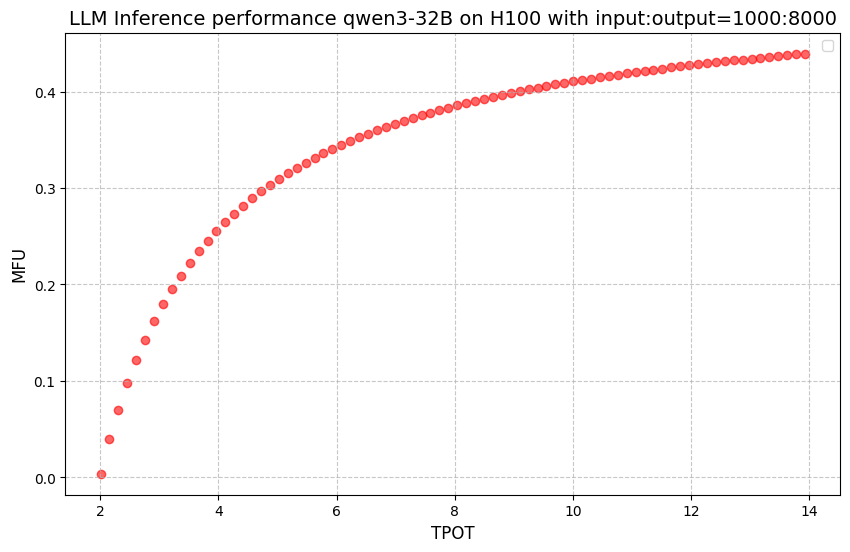

In [8]:

import matplotlib.pyplot as plt
def draw_optimal_diagram(hardware, model, dtype, input, output, b_list, tp_list, speculative):
    h = hardware_map[hardware]
    m = model_map[model]
    d = dtype_map[dtype]
    max_mfu = 0.6
    x_points = []
    y_points = []

    for tp in tp_list:
        for b in b_list:
            flops = 2 * b * m.m_compute * 1e9 / tp / d.compute_factor + 2 * b * (input+output) * m.q_head * m.head_dim * m.layer_num / tp / d.compute_factor
            if tp > 1:
                nvlink = 4 * b * m.hidden_dim * m.layer_num * d.w_factor
            else:
                nvlink = 0

            kv_bw = b * output * (2 * input + output) * m.kv_head * m.head_dim * m.layer_num * d.w_factor / ((input + output) *tp * speculative)
            all_bw =  m.m_params * 1e9 * d.w_factor / (tp)  + kv_bw

            compute_comm_time = flops / (h.flops * 1e12 * max_mfu) + nvlink / (h.w_nvlink * 1e9)
            bw_time = all_bw / (h.bw * 1e9)

            step = max(compute_comm_time, bw_time)

            tpot = step / speculative * 1000
            mfu = flops  / (h.flops * step * 1e12)

            x_points.append(tpot)
            y_points.append(mfu)
    

    plt.figure(figsize=(10, 6))

    plt.scatter(x_points, y_points, c='r', alpha=0.6)

    plt.title(f'LLM Inference performance {model} on {hardware} with input:output={input}:{output}', fontsize=14)
    plt.xlabel('TPOT', fontsize=12)
    plt.ylabel('MFU', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.savefig('images/llm-inference/roofline.png')
    plt.show()

            
draw_optimal_diagram("H100", "qwen3-32B", "w16a16c16", 1000, 8000, [i for i in range (1,800,10)], [4], 2.4)
            

    

With that, we know the roofline performance for LLM inference. We can pick a dot in the diagram with expected TPOT for deployment. When you actually deploy the model, you may found that the performance is not as expected. There are still tones of optimizations we need to implement in the LLM serving stack to actually acheive the optimal performance. Here I will highlight a couple important ones you can further investigage and their expected impact:
- **quantization** : Quantization can both accelerate compuation and reduce memory bandwidth usage. I briefly mentioned int8/fp8 qunantization in this blog. The actual quantization technique is much more complex. Expected impact: 30~70% throughput/latency improvements.
- **sync scheduler**: ML hardware is getting faster and faster. We don't want slow CPU to interfere GPU execution. Async scheduler is critical to allow CPU doing all the preparation ahead of the time. Expected impact: 30% throughput improvements.
- **Advanced model parallelism**: TP has limitations, we need to bundle it with other model parallelism strategy to achieve best performance. Expected impact: 10% througput, +2x latency improvements.
- **Hetrogenous hardware**: I mentioned in the blog that prefill-decode disaggregation can leverage heterogenous hardware. And there are some model parallelism strategies can leverage heterogenous hardware as well. Using a cheaper hardware can largely reduce the overall cost for LLM inference. Expected impact: +2x cost improvements.